In [7]:
#Winston Shih
#WXS190012
#MATH 4332 HW 9
#1
import numpy as np
def my_bisection(f, a, b, tol):
     R = [(a + b) / 2]
     E = [abs(f(R[0]))]
     i = 0
     while E[-1] >= tol:
        if f(a) * f(R[i]) < 0:
          b = R[i]
        else:
          a = R[i]
        i += 1
        R.append((a + b) / 2)
        E.append(abs(f(R[i])))
     return R, E
# Program 1
f = lambda x: x**2 - 2
[R, E] = my_bisection(f, 0, 2, 1e-1)
print([R, E])
# Program 2
f = lambda x: np.sin(x) - np.cos(x)
[R, E] = my_bisection(f, 0, 2, 1e-2)
print([R,E])

[[1.0, 1.5, 1.25, 1.375, 1.4375], [1.0, 0.25, 0.4375, 0.109375, 0.06640625]]
[[1.0, 0.5, 0.75, 0.875, 0.8125, 0.78125], [np.float64(0.30116867893975674), np.float64(0.39815702328616975), np.float64(0.050050108850486774), np.float64(0.126546644072702), np.float64(0.038323093040207756), np.float64(0.005866372111545948)]]


Y = 0.5401785714285714


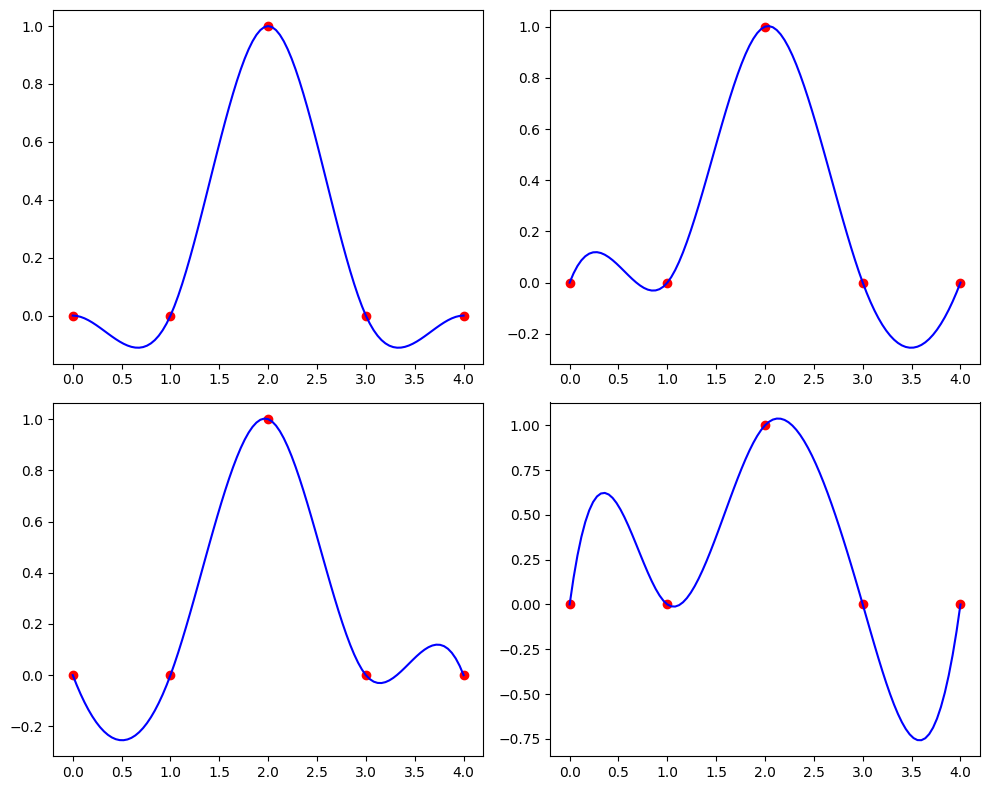

In [ ]:
#2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
def my_D_cubic_spline(x, y, X, D):
    cs = CubicSpline(x, y, bc_type=((1, D), (1, D)))
    Y = cs(X)
    return Y
x = [0, 1, 2, 3, 4]
y = [0, 0, 1, 0, 0]
X = np.linspace(0, 4, 101)
# Solution: Y = 0.54017857
Y = my_D_cubic_spline(x, y, 1.5, 1)
print(f"Y = {Y}")
plt.figure(figsize=(10, 8))
plt.subplot(221)
plt.plot(x, y, 'ro', X, my_D_cubic_spline(x, y, X, 0), 'b')
plt.subplot(222)
plt.plot(x, y, 'ro', X, my_D_cubic_spline(x, y, X, 1), 'b')
plt.subplot(223)
plt.plot(x, y, 'ro', X, my_D_cubic_spline(x, y, X, -1), 'b')
plt.subplot(224)
plt.plot(x, y, 'ro', X, my_D_cubic_spline(x, y, X, 4), 'b')
plt.tight_layout()
plt.show()

In [ ]:
#3
import numpy as np
import sympy as sp
def divided_diff(x, y):
  n = len(y)
  coef = np.zeros([n, n])
  coef[:, 0] = y
  for j in range(1, n):
    for i in range(n - j):
      coef[i][j] = (coef[i + 1][j - 1] - coef[i][j - 1]) / (x[i + j] - x[i])
  return coef
def newton_poly(coef, x_data, x):
  n = len(x_data) - 1
  p = coef[0][n]
  for k in range(1, n + 1):
    p = coef[0][n - k] + (x - x_data[n - k]) * p
  return p
x_data = [0, 1, 2, 3, 4]
y_data = [2, 1, 3, 5, 1]
coef = divided_diff(x_data, y_data)

n = len(x_data) - 1
expression = str(coef[0][0])
for k in range(1, n + 1):
      term = str(coef[0][k])
      for j in range(k):
          term += f"(x - {x_data[j]})"
      expression += f" + {term}"

print("P(x) = " + expression.replace("1.0*(", "("))
print(f"Degree of the polynomial: {len(x_data)-1}")


P(x) = 2.0 + -1.0(x - 0) + 1.5(x - 0)(x - 1) + -0.5(x - 0)(x - 1)(x - 2) + -0.125(x - 0)(x - 1)(x - 2)(x - 3)
Degree of the polynomial: 4


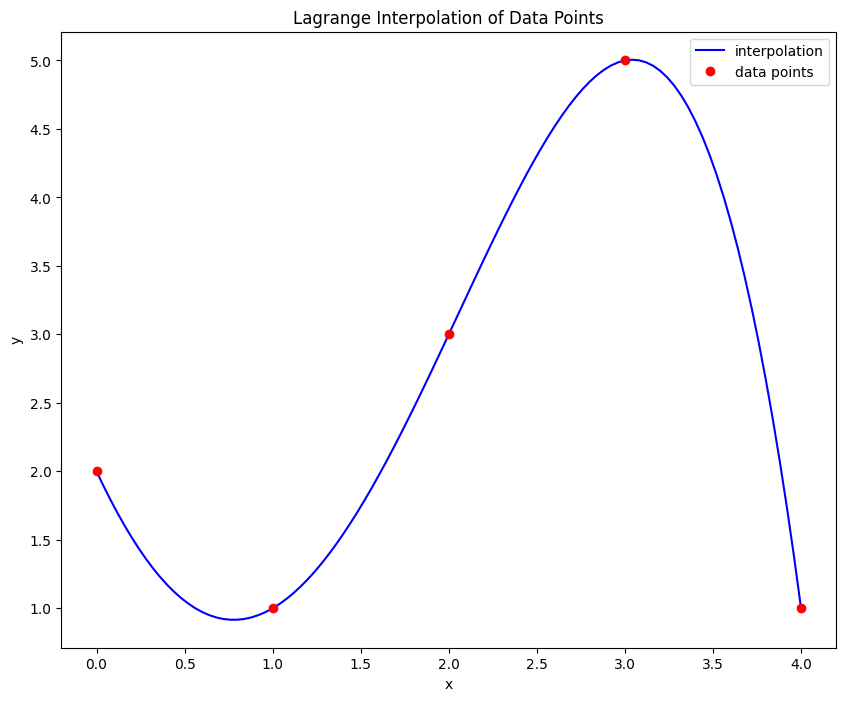

In [ ]:
#4
import numpy as np
import matplotlib.pyplot as plt
def my_lagrange(x, y, X):
  n = len(x)
  Y = np.zeros(len(X))
  for i in range(len(X)):
    for j in range(n):
      L = 1.0
      for k in range(n):
        if k != j:
          L *= (X[i] - x[k]) / (x[j] - x[k])
      Y[i] += y[j] * L
  return Y
x = [0, 1, 2, 3, 4]
y = [2, 1, 3, 5, 1]
X = np.linspace(0, 4, 101)
plt.figure(figsize=(10, 8))
plt.plot(X, my_lagrange(x, y, X), 'b', label='interpolation')
plt.plot(x, y, 'ro', label='data points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange Interpolation of Data Points')
plt.legend()
plt.show()

In [ ]:
#5
def my_newton(f, df, x0, tol):
    R=[x0]
    E=[abs(f(x0))]
    i=0
    while E[i]>=tol:
        x0=x0-f(x0)/df(x0)
        R.append(x0)
        E.append(abs(f(x0)))
        i+=1
    return R, E

f = lambda x: x**2 - 2
df = lambda x: 2*x
[R, E] = my_newton(f, df, 1, 1e-5)
print([R,E])
f = lambda x: np.sin(x) - np.cos(x)
df = lambda x: np.cos(x) + np.sin(x)
[R, E] = my_newton(f, df, 1, 1e-5)
print([R,E])

[[1, 1.5, 1.4166666666666667, 1.4142156862745099], [1, 0.25, 0.006944444444444642, 6.007304882871267e-06]]
[[1, np.float64(0.782041901539138), np.float64(0.7853981759997019)], [np.float64(0.30116867893975674), np.float64(0.004746462127804163), np.float64(1.7822277875723103e-08)]]
